In [35]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/horse-or-human.zip \
    -O ./horse-or-human.zip

import os
import zipfile

local_zip = './horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('./horse-or-human')
zip_ref.close()

--2026-03-11 09:01:47--  https://storage.googleapis.com/learning-datasets/horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149574867 (143M) [application/zip]
Saving to: ‘./horse-or-human.zip’

./horse-or-human.zi 100%[===================>] 142.65M   306MB/s    in 0.5s    

2026-03-11 09:01:48 (306 MB/s) - ‘./horse-or-human.zip’ saved [149574867/149574867]



In [36]:
#directory with training horse pictures
train_horse_dir= os.path.join('./horse-or-human/horses')

#Directory with training human pictures
train_human_dir= os.path.join('./horse-or-human/humans')


In [37]:
train_horse_names = os.listdir(train_horse_dir)
print(train_horse_names[:10])

train_human_names = os.listdir(train_human_dir)
print(train_human_names[:10])

['horse05-3.png', 'horse12-6.png', 'horse23-6.png', 'horse47-7.png', 'horse11-7.png', 'horse19-3.png', 'horse32-4.png', 'horse11-2.png', 'horse41-0.png', 'horse20-8.png']
['human05-21.png', 'human12-19.png', 'human14-20.png', 'human10-14.png', 'human12-30.png', 'human05-05.png', 'human13-29.png', 'human06-02.png', 'human13-09.png', 'human01-28.png']


In [38]:
print('total training horse images:', len(os.listdir(train_horse_dir)))
print('total training human images:', len(os.listdir(train_human_dir)))

total training horse images: 500
total training human images: 527


In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Parameters for our graph: we'll output iages in 4x4 configuration
nrows=4
ncols=4

#Index for iterating over images
pic_index=0

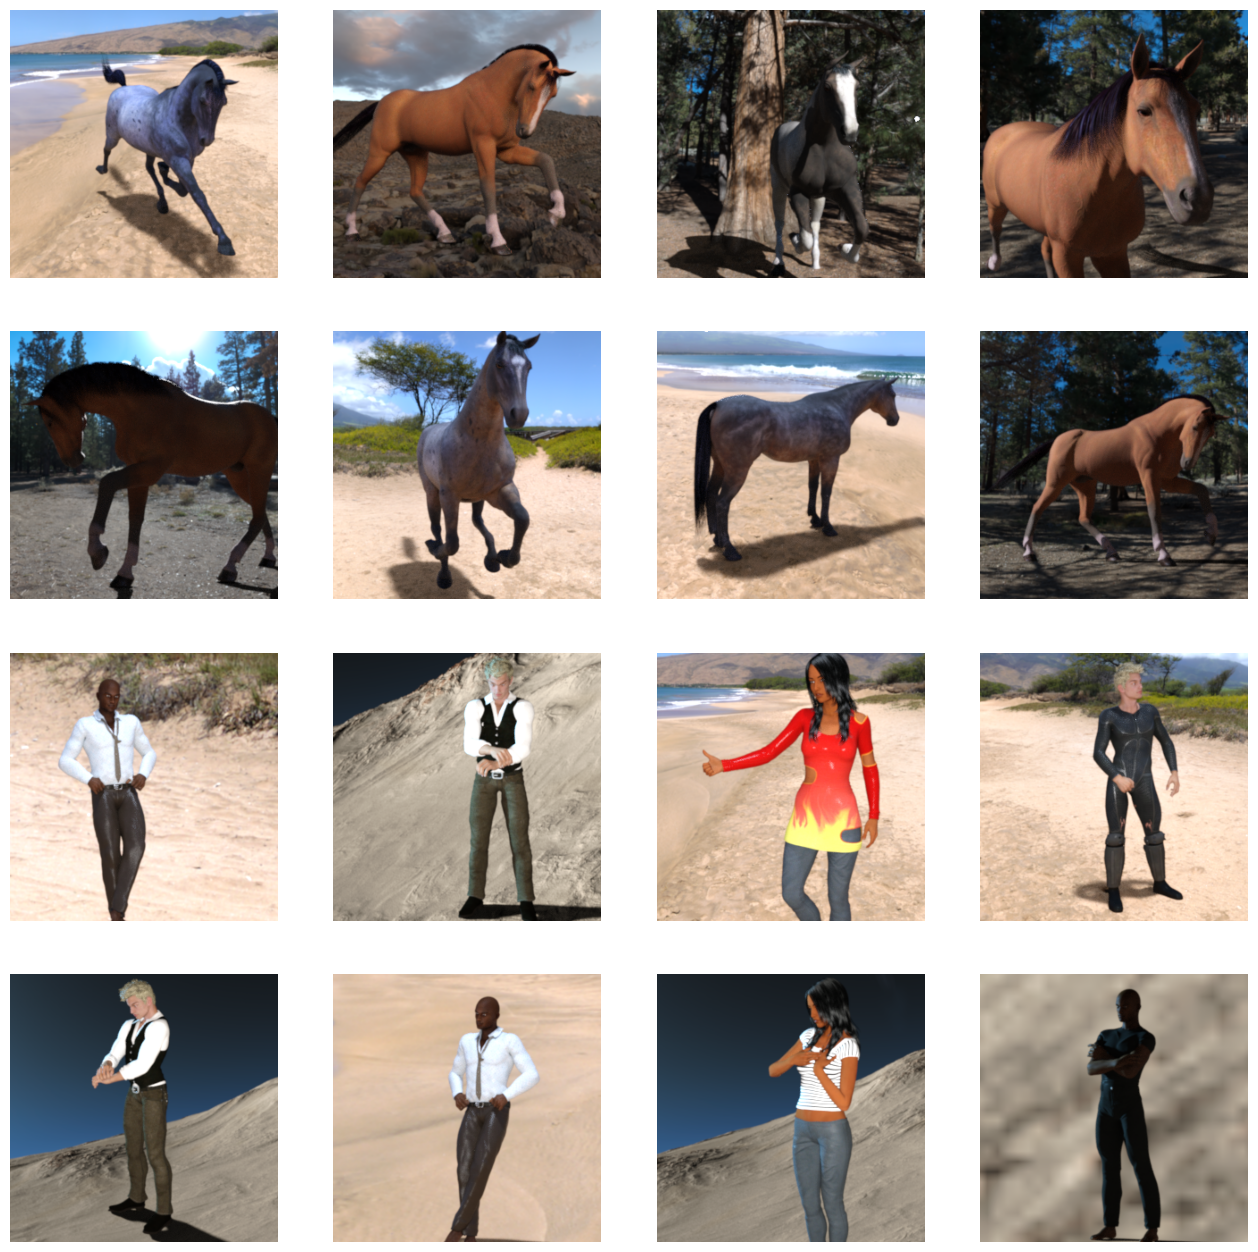

In [40]:
#setup matplotlib figs, and and size it to fit 4x4 pics
fig= plt.gcf()
fig.set_size_inches(ncols * 4, nrows*4)

pic_index+=8
next_horse_pix=[os.path.join(train_horse_dir, fname)
               for fname in train_horse_names[pic_index-8:pic_index]]
next_human_pix=[os.path.join(train_human_dir, fname)
               for fname in train_human_names[pic_index-8:pic_index]]

for i,img_path in enumerate(next_horse_pix+next_human_pix):
    #set up subplot; subplot indices start at 1
    sp=plt.subplot(nrows, ncols, i+1)
    sp.axis('Off') #Dont show axes

    img=mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

In [41]:
import tensorflow as tf

In [42]:
model= tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 300x300 with 3 bytes color
    #This is the first convolution
    tf.keras.layers.Conv2D(16,(3,3), activation='relu', input_shape=(300,300,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    #The second convolution
    tf.keras.layers.Conv2D(32,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    #Third convolution
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    #Fourth convolution
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    #Fifth convolution
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    #Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    #512 hidden neurons
    tf.keras.layers.Dense(512, activation='relu'),
    #Only 1 output neuron. It will contain a value from 0-1 where 0 afor class (horses) and 1 for [human]
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 33, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,097 (6.50 MB)

 Trainable params: 1,704,097 (6.50 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
from tensorflow.keras.optimizers import RMSprop
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch, logs={}):
    if(logs.get('accuracy')>0.96):
      print("\n Reached 99% accuracy so cancelling training!")
      self.model.stop_training = True
callbacks=myCallback()

model.compile(loss='binary_crossentropy',
             optimizer=RMSprop(learning_rate=0.001),
             metrics=['accuracy'])

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#All images will be rescaled by 1/255
train_datagen = ImageDataGenerator(rescale=1/255)

#Flow training images in batchea of 128 using trIN_datagen generator
train_generator = train_datagen.flow_from_directory(
        './horse-or-human/', #This is the source directory for training images
        target_size=(300,300), #All images will be resized to 300x300
        batch_size=128,
        #Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary',

        )

Found 1027 images belonging to 2 classes.


In [50]:
history= model.fit(
    train_generator,
    steps_per_epoch=8,
    epochs=15,
    verbose=1,
    callbacks=[callbacks]
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 919ms/step - accuracy: 0.8505 - loss: 0.8213
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8906 - loss: 0.3151  
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 853ms/step - accuracy: 0.8995 - loss: 0.2560
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9375 - loss: 0.1863  
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 927ms/step - accuracy: 0.9464 - loss: 0.1436
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2548  
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 986ms/step - accuracy: 0.9350 - loss: 0.1622
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6667 - loss: 1.3949 
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 899ms/step - accuracy: 0.6854 - loss: 2.0959
Epoch 10/15
1/8 ━━━━━━━━━━━━━━━━━━━━ 6s 965ms/step - accuracy: 0.9766 - loss: 0.1191
 Reached 99% accuracy so cancelling training!
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.1191  


In [53]:
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
   #predicting images
   path= '/content/' +fn
   img= image.load_img(path, target_size=(300,300))
   x= image.img_to_array(img)
   x = np.expand_dims(x, axis=0)

   images = np.vstack([x])
   classes = model.predict(images, batch_size=10)
   print(classes[0])

   if classes[0]>0.5:
    print(fn + "is a human")
   else:
    print(fn + "is a horse")

Saving images (1).jpg to images (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step
[0.]
images (1).jpgis a horse
